# supp_fig - Part 2/5\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


In [ ]:
np.log10(1+8*NZ)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

unique_clusters = np.unique(labels)
n_clust = len(unique_clusters)
colors = plt.cm.tab10(np.arange(n_clust) % 10)  # 每个 cluster 一个颜色

motif_groups = [
    (list(range(0, 4)),  "Motifs 1–4"),
    (list(range(4, 8)),  "Motifs 5–8"),
    (list(range(8, 13)), "Motifs 9–13"),
]

for idx_group, (motif_idx_list, title_group) in enumerate(motif_groups, 1):
    n_motifs = len(motif_idx_list)
    n_cols = 2
    n_rows = int(np.ceil(n_motifs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

    for k, j in enumerate(motif_idx_list):
        row = k // n_cols
        col = k % n_cols
        ax = axes[row, col]

        vals = NZ[:, j]  # 该 motif 的 NZ-score，所有脑区
        data_by_cluster = [vals[labels == c] for c in unique_clusters]

        # violin
        parts = ax.violinplot(
            data_by_cluster,
            positions=np.arange(1, n_clust + 1),
            showmeans=True,
            showextrema=False,
            showmedians=False,
        )

        # 统一 violin 颜色：每个 cluster 一个颜色
        for body, col_c in zip(parts['bodies'], colors):
            body.set_facecolor(col_c)
            body.set_edgecolor(col_c)
            body.set_alpha(0.5)

        # 在每个 cluster 上叠点，颜色与对应的 violin 一致
        for i, c in enumerate(unique_clusters, start=1):
            mask = (labels == c)
            vals_c = vals[mask]
            jitter = (np.random.rand(len(vals_c)) - 0.5) * 0.15
            x_pos = np.full(len(vals_c), i) + jitter
            ax.scatter(x_pos, vals_c, s=15, alpha=0.9, color=colors[i-1])

        ax.set_xticks(np.arange(1, n_clust + 1))
        ax.set_xticklabels([f"C{int(c)}" for c in unique_clusters], fontsize=9)
        ax.axhline(0, color="k", lw=1)
        ax.set_ylabel("NZ-score")
        ax.set_title(f"Motif {j+1}")

    # 把多出来的空 subplot 删掉
    for k in range(n_motifs, n_rows * n_cols):
        row = k // n_cols
        col = k % n_cols
        fig.delaxes(axes[row, col])

    fig.suptitle(f"Motif NZ-score across clusters ({title_group})", fontsize=14)
    plt.tight_layout()
    plt.show()

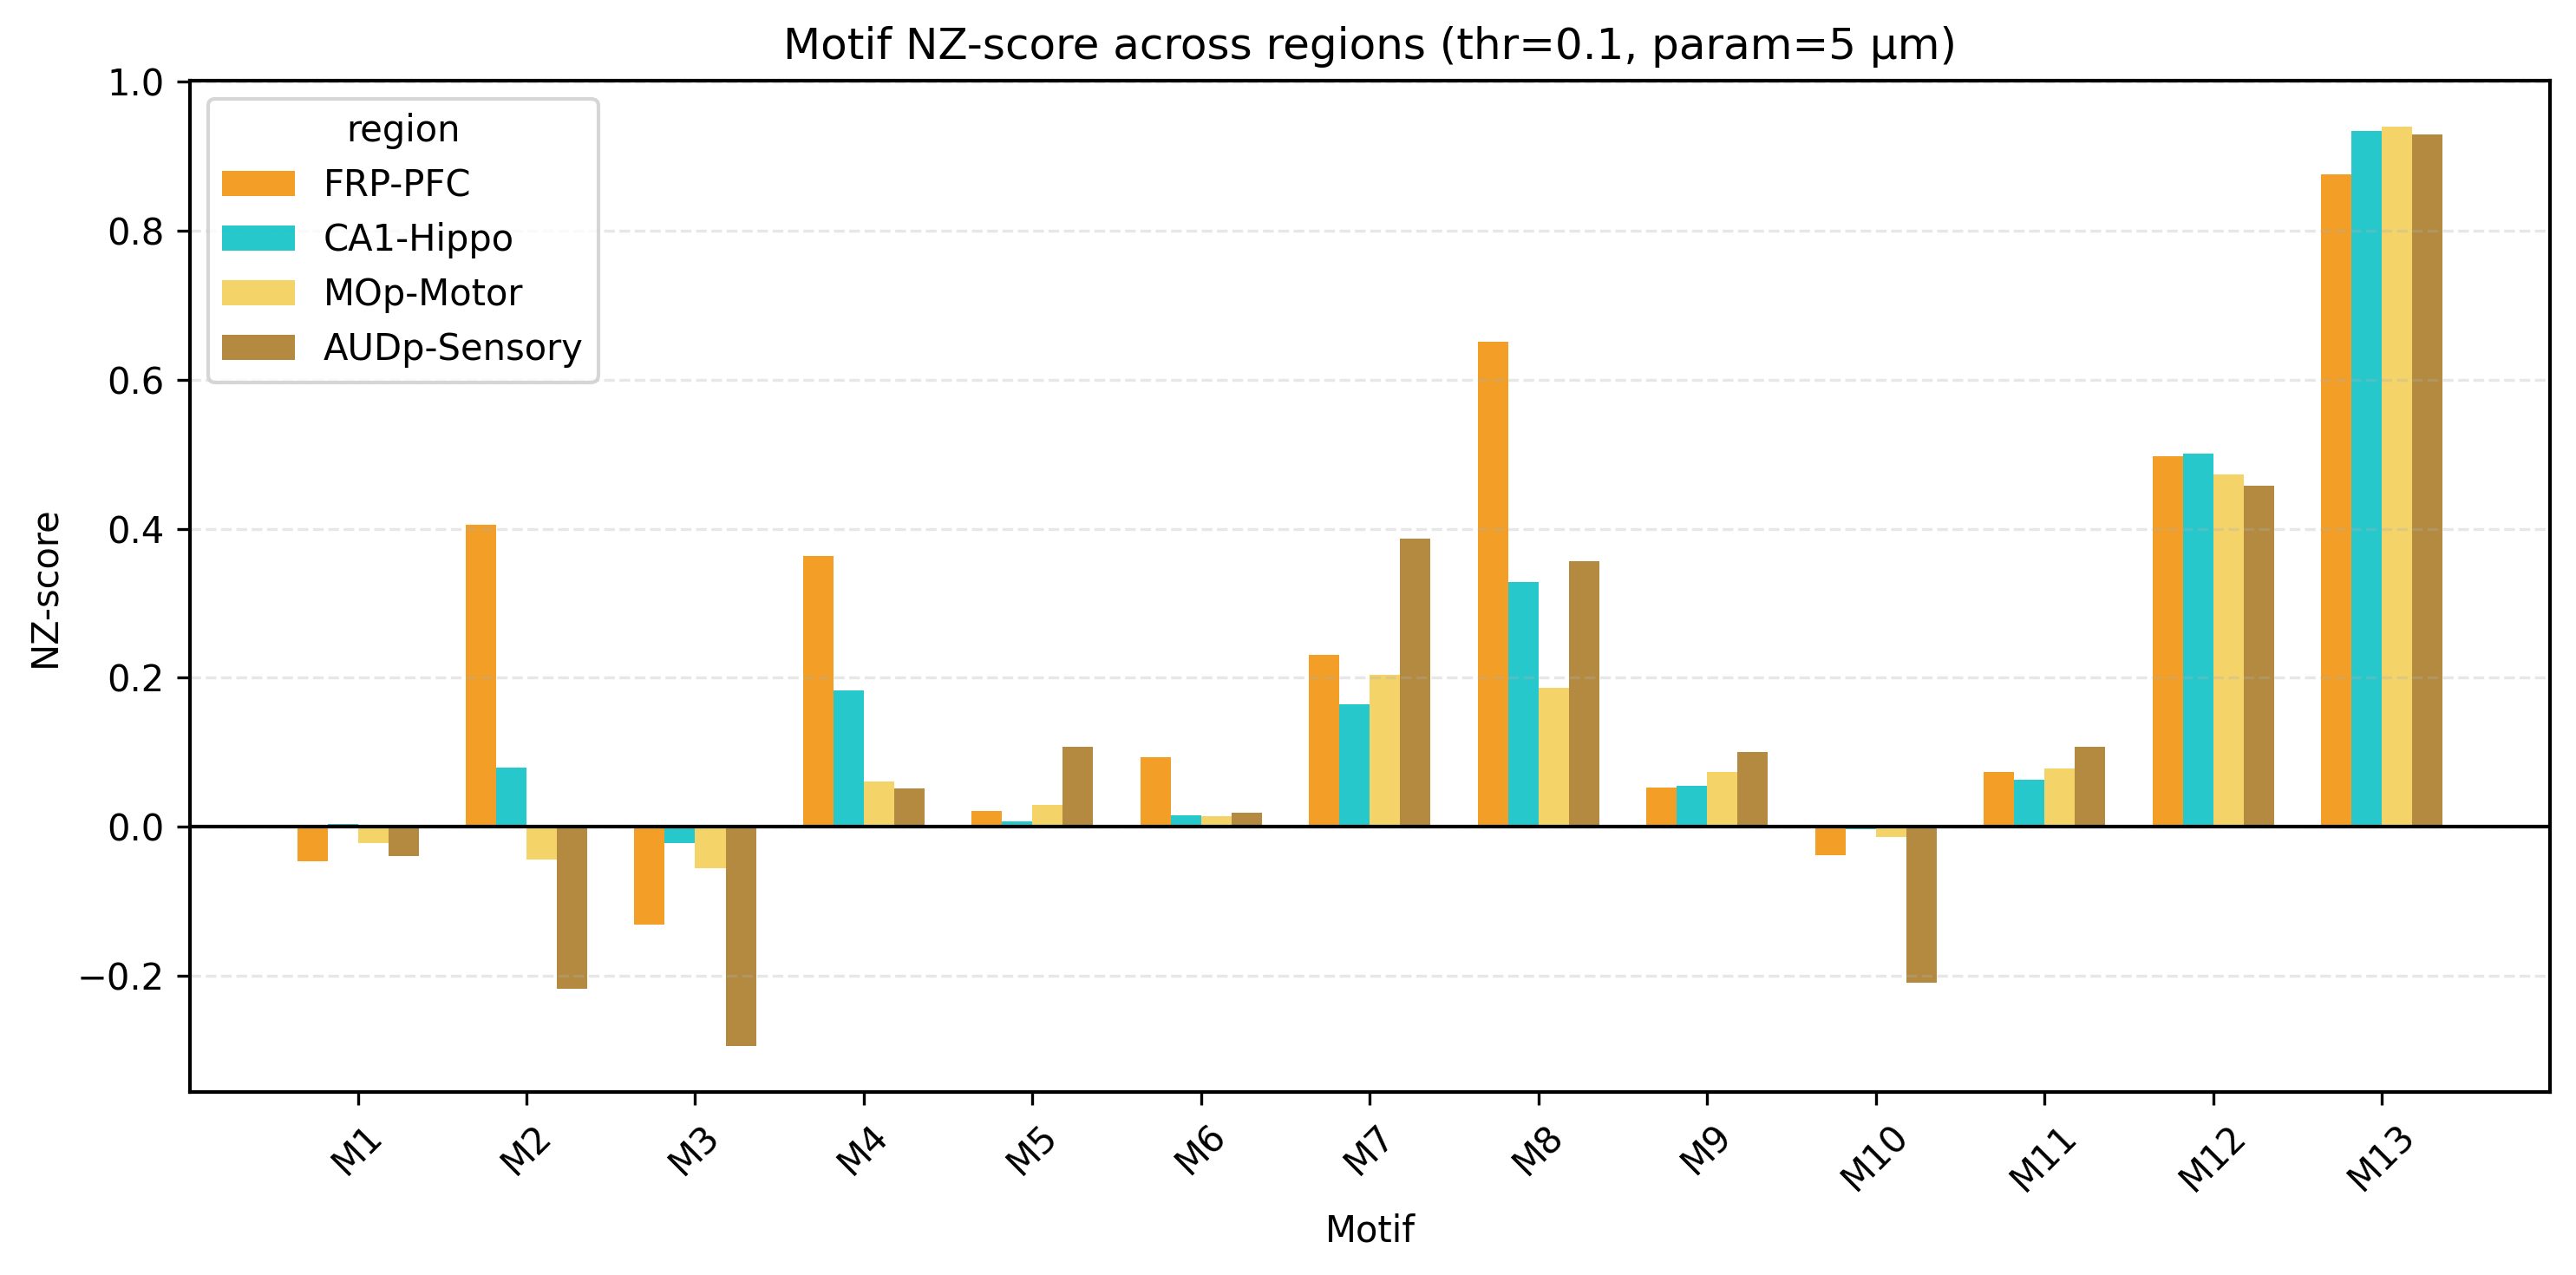

In [45]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. Basic params =====
pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
param = 5
thr_pick = "0.1"  # choose ONE: "0", "0.1", "0.2", "0.3", "0.4"
regions = ["FRP", "CA1", "MOp", "AUDp"]
regions_label =  ["FRP-PFC", "CA1-Hippo", "MOp-Motor", "AUDp-Sensory"]
# ===== 1. Load =====
with open(pkl_path, "rb") as f:
    results = pickle.load(f)["results"]




# ===== 2. Collect NZ for each region at the same threshold =====
nz_mat = []
valid_regions = []
for r in regions:
    mr = results[param][r]["motif_results"].get(thr_pick, None)
    if mr is None:
        print(f"[WARN] missing: region={r}, thr={thr_pick}")
        continue
    nz = np.asarray(mr["NZ"], float)
    if nz.shape[0] != 13:
        print(f"[WARN] bad NZ shape: region={r}, shape={nz.shape}")
        continue
    nz_mat.append(nz)
    valid_regions.append(r)

nz_mat = np.log10(1+8*np.vstack(nz_mat))  # (n_region, 13)

# ===== 3. Plot grouped bars (4 regions) =====
x = np.arange(13)
bw = 0.18

colors = {
    "MOp-E":   "#601986",
    "MOp":     "#F3CC4F",
    "AVE":     "#009944",
    "FRP":     "#F18D00",
    "FRP-E":   "#E60012",
    "Vanilla": "#529DCB",
    "CA1":     "#00BFC4",
    "AUDp":    "#A6761D"
}
# colors = plt.cm.tab10(np.arange(n_clust) % 10)

# colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(valid_regions)))

plt.figure(figsize=(10, 5))
for i, r in enumerate(valid_regions):
    plt.bar(x + (i - (len(valid_regions)-1)/2)*bw, nz_mat[i], width=bw,
            alpha=0.85, color=colors[r], label=regions_label[i])

plt.xticks(x, [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("NZ-score")
plt.xlabel("Motif")
plt.title(f"Motif NZ-score across regions (thr={thr_pick}, param={param} µm)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="region")
plt.tight_layout()
plt.savefig(f"8.NZ_regions_FRP_CA1_MOp_AUDp_thr{thr_pick}_param{param}.svg",
            bbox_inches="tight", transparent=True)
plt.show()

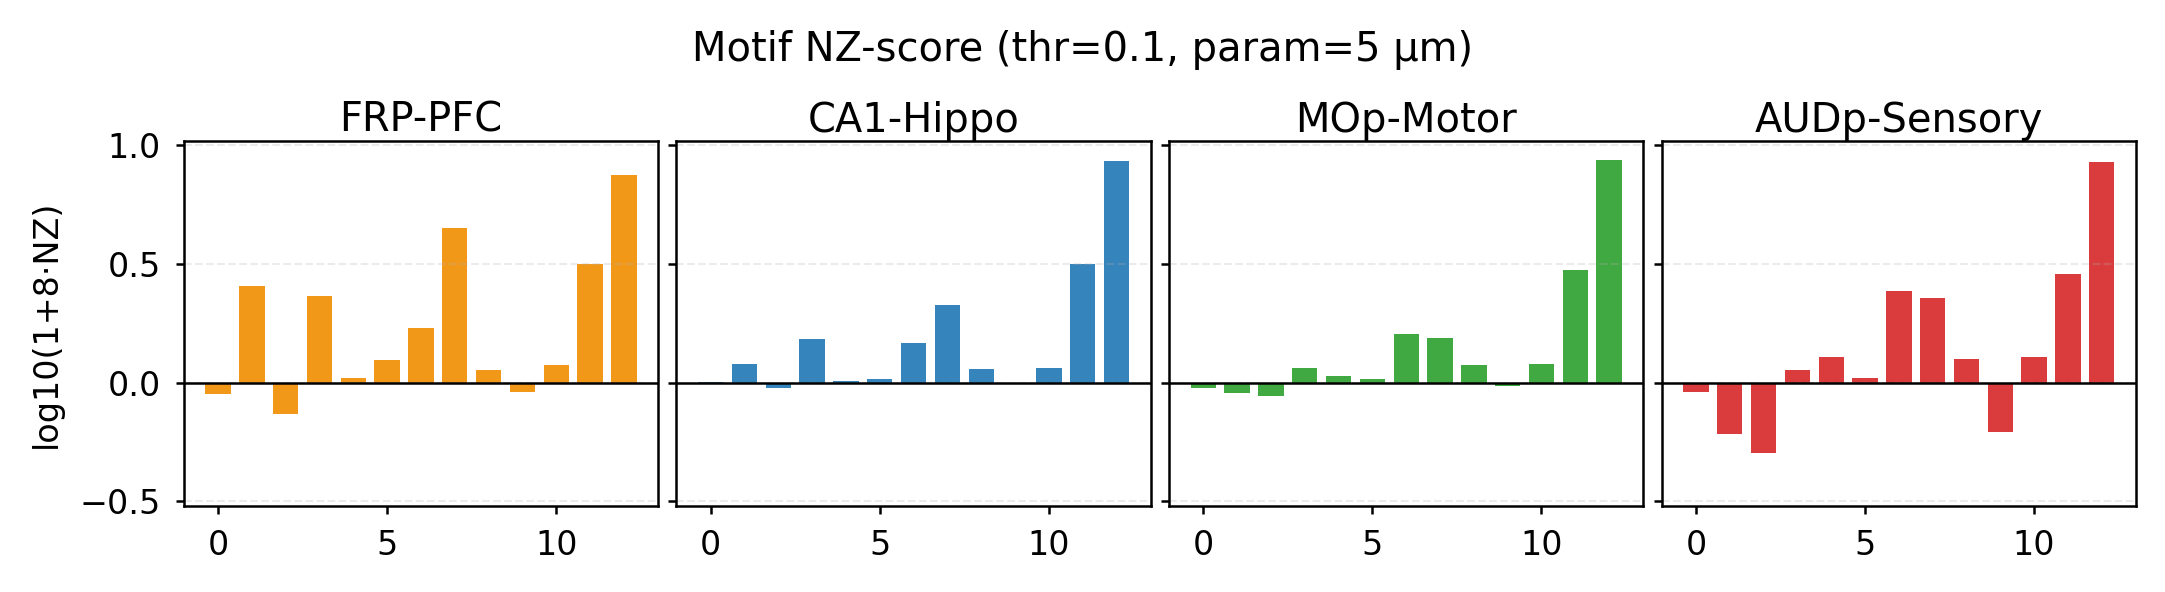

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===== 0. Basic params =====
pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
param = 5
thr_pick = "0.1"  # "0", "0.1", "0.2", "0.3", "0.4"
regions = ["FRP", "CA1", "MOp", "AUDp"]
regions_label = ["FRP-PFC", "CA1-Hippo", "MOp-Motor", "AUDp-Sensory"]

# ===== style for small panels =====
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["font.size"] = 8
mpl.rcParams["axes.linewidth"] = 0.6
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

colors = {
    "FRP":     "#F18D00",
    "CA1":     "#1f77b4",
    "MOp":     "#2ca02c",
    "AUDp":    "#d62728"
}

# colors = plt.cm.tab10(np.arange(n_clust) % 10)

# ===== 1. Load =====
with open(pkl_path, "rb") as f:
    results = pickle.load(f)["results"]

# ===== 2. Collect NZ for each region at the same threshold =====
nz_mat, valid_regions, valid_labels = [], [], []
for r, lab in zip(regions, regions_label):
    mr = results[param][r]["motif_results"].get(thr_pick, None)
    if mr is None:
        print(f"[WARN] missing: region={r}, thr={thr_pick}")
        continue
    nz = np.asarray(mr["NZ"], float)
    if nz.shape != (13,):
        print(f"[WARN] bad NZ shape: region={r}, shape={nz.shape}")
        continue
    nz_mat.append(nz)
    valid_regions.append(r)
    valid_labels.append(lab)

nz_mat = np.log10(1 + 8 * np.vstack(nz_mat))  # (n_region, 13)

# ===== 3. 4 panels: one bar chart per region =====
x = np.arange(13)

# y-limits统一，方便横向比较
ymin = float(np.nanmin(nz_mat))
ymax = float(np.nanmax(nz_mat))
pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.2
ylims = (-0.52, 1.02)

fig_w_cm, fig_h_cm = 18.0, 4.5  # 一行四图
fig, axes = plt.subplots(1, len(valid_regions), figsize=(fig_w_cm/2.54, fig_h_cm/2.54), sharey=True)

if len(valid_regions) == 1:
    axes = [axes]

for ax, r, lab, y in zip(axes, valid_regions, valid_labels, nz_mat):
    ax.bar(x, y, width=0.75, color=colors[r], alpha=0.9, linewidth=0)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(lab, pad=2)
    # ax.set_xticks(x)
    # ax.set_xticklabels([f"M{i}" for i in range(1, 14)], rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.25, linewidth=0.5)
    ax.set_ylim(*ylims)
    ax.tick_params(axis="both", which="both", width=0.6, length=2.0)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)

axes[0].set_ylabel("log10(1+8·NZ)")
fig.suptitle(f"Motif NZ-score (thr={thr_pick}, param={param} µm)", y=1.02)

plt.tight_layout(pad=0.3)
plt.savefig(f"8.NZ_4panels_FRP_CA1_MOp_AUDp_thr{thr_pick}_param{param}.svg",
            bbox_inches="tight", transparent=True)
plt.show()

In [58]:
colors

array([[0.12156863, 0.46666667, 0.70588235, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       [0.17254902, 0.62745098, 0.17254902, 1.        ],
       [0.83921569, 0.15294118, 0.15686275, 1.        ]])

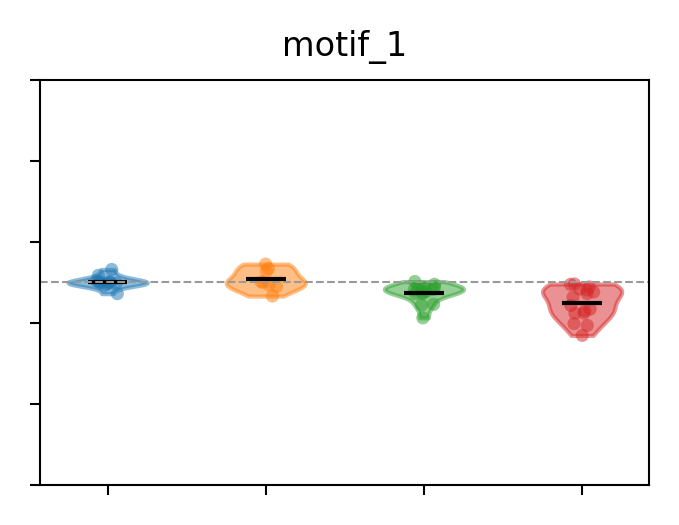

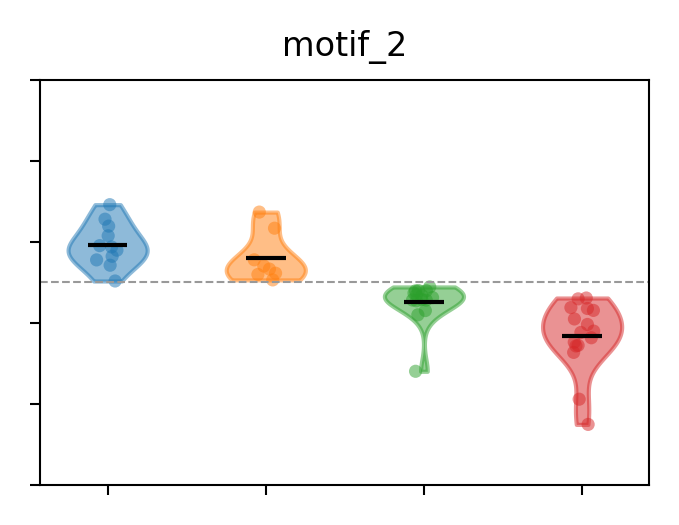

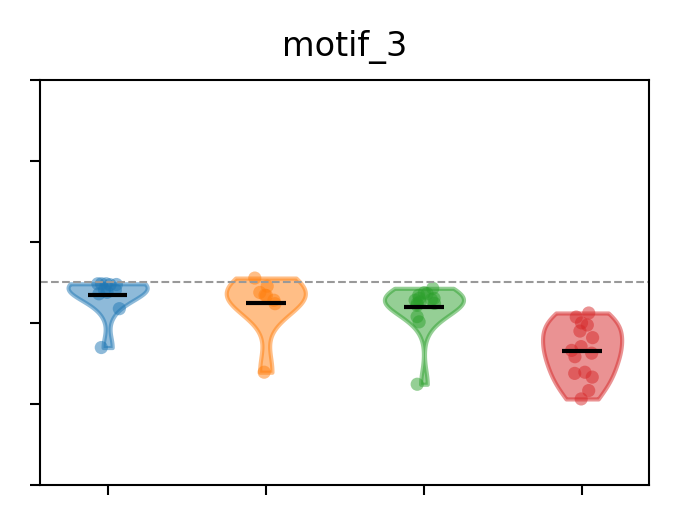

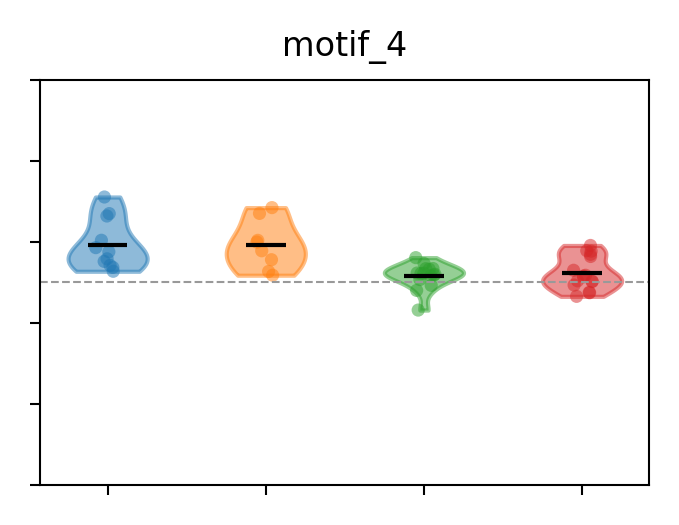

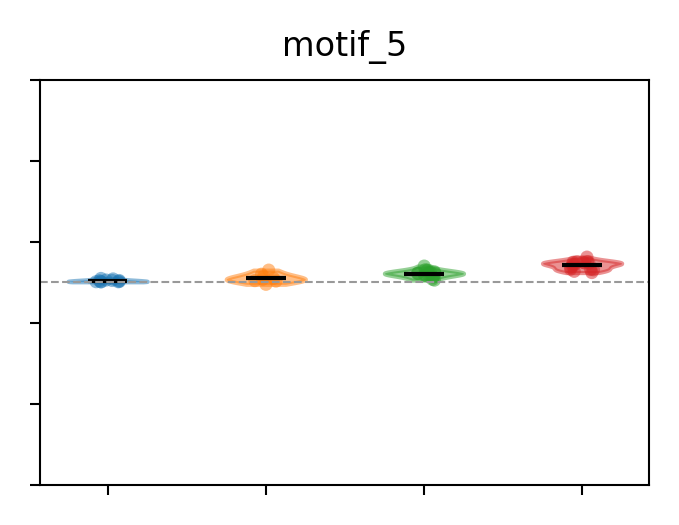

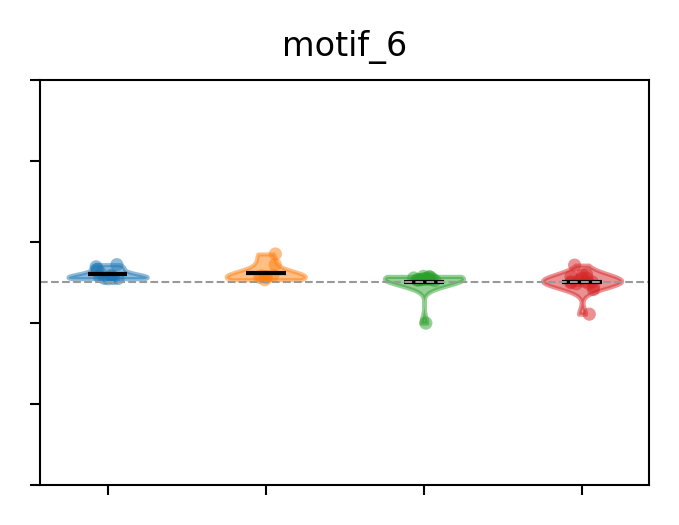

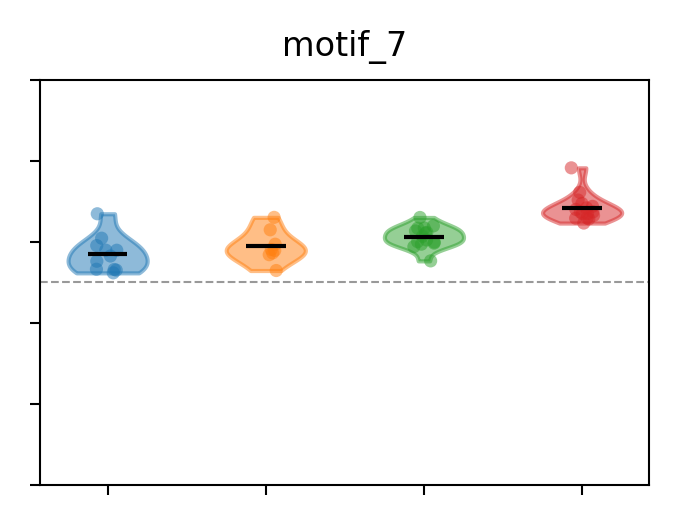

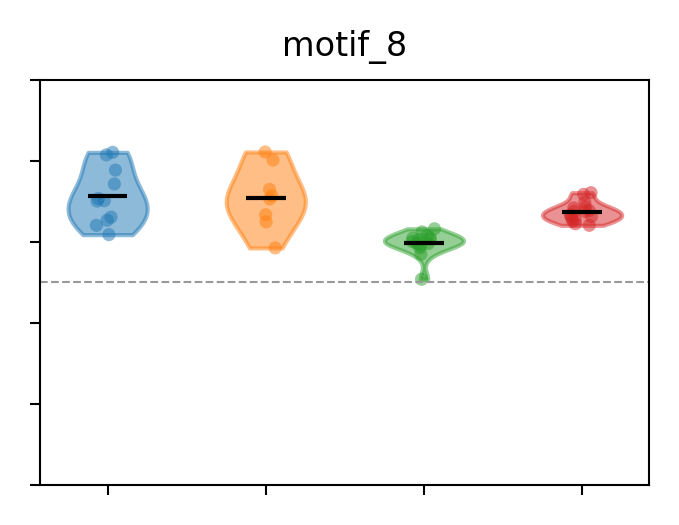

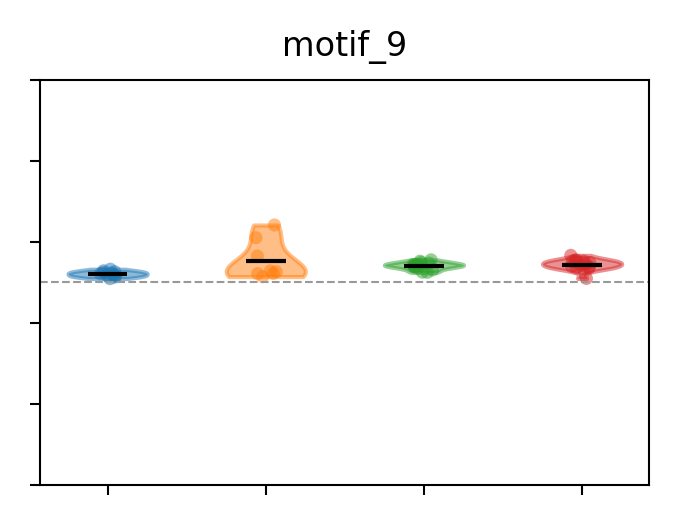

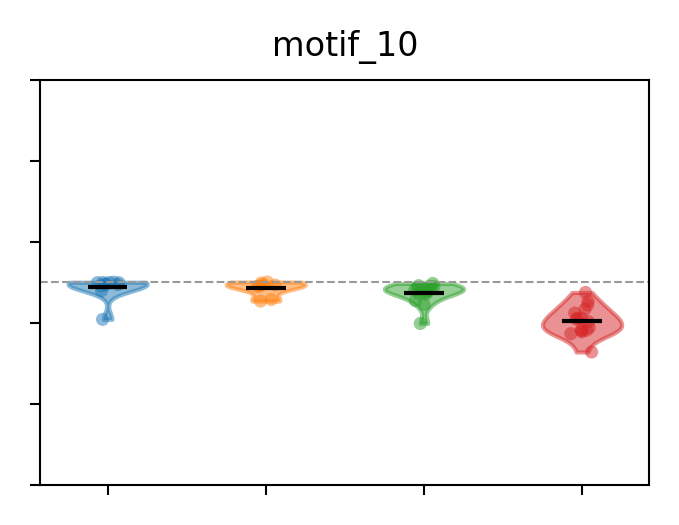

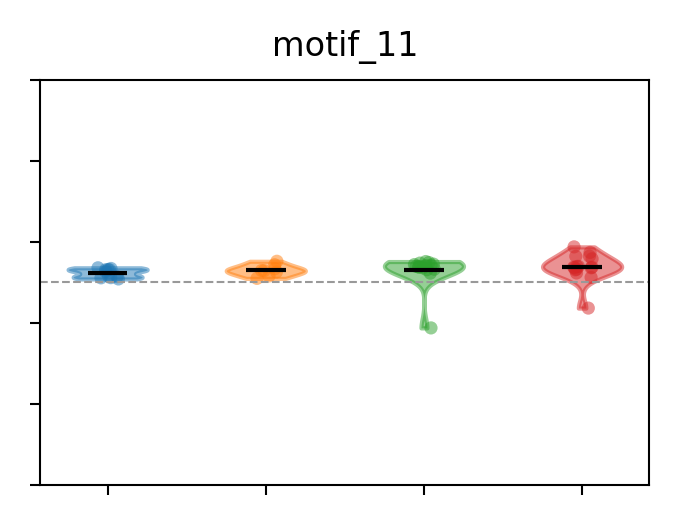

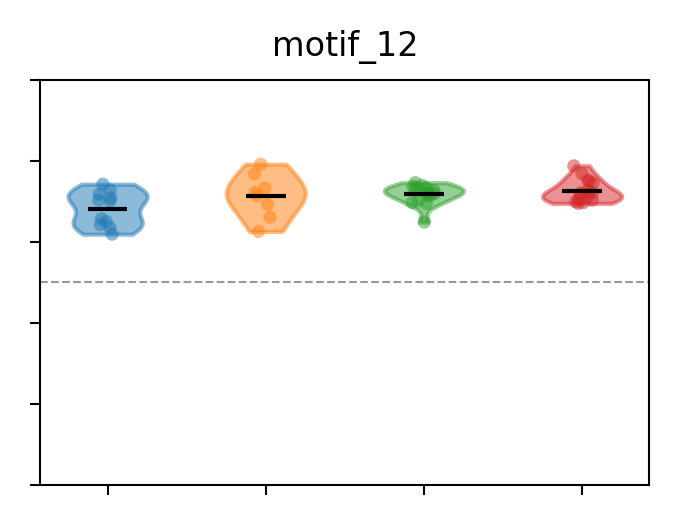

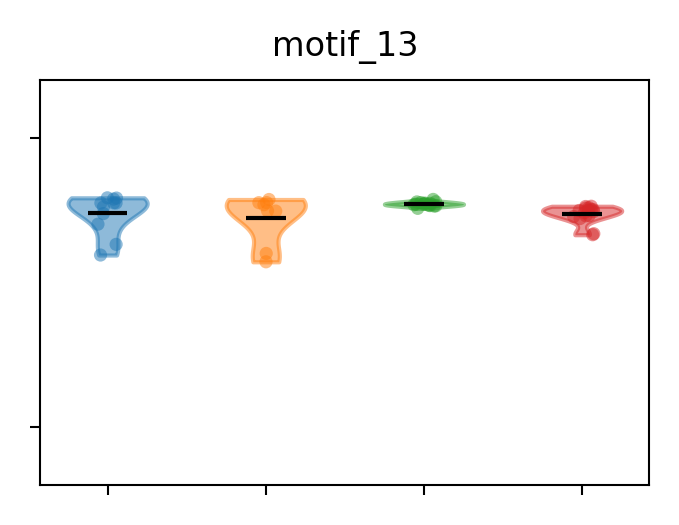

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ===========================
# Assumed existing:
# NZ     : (n_region, 13)
# labels : (n_region,)  values in {1,2,3,4} (can include 0 if unassigned)
# ===========================

# ----- Figure size (cm -> inch) -----
fig_w_cm, fig_h_cm = 5.3, 4.0
fig_w_in, fig_h_in = fig_w_cm / 2.54, fig_h_cm / 2.54

# ----- Cluster info / colors / test pairs -----
unique_clusters = np.array(sorted(np.unique(labels).tolist()))
n_clust = len(unique_clusters)
colors = plt.cm.tab10(np.arange(n_clust) % 10)

pairs = [(1, 2), (2, 3), (3, 4), (1, 4)]  # C1-C2, C2-C3, C3-C4, C1-C4

for j in range(13):
    # ----- 0) transform + drop invalid values (per motif) -----
    raw = 1 + 7 * NZ[:, j]
    mask = np.isfinite(raw) & (raw > 0) & np.isfinite(labels)
    vals = np.log10(raw[mask])
    labj = labels[mask]

    fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

    # ----- 1) violin data by cluster -----
    data_by_cluster = [vals[labj == c] for c in unique_clusters]

    parts = ax.violinplot(
        data_by_cluster,
        positions=np.arange(1, n_clust + 1),
        showmeans=True,
        showextrema=False,
        showmedians=False,
    )

    # violin colors
    for body, col in zip(parts["bodies"], colors):
        body.set_facecolor(col)
        body.set_edgecolor(col)
        body.set_alpha(0.5)

    # mean line styling
    if "cmeans" in parts and parts["cmeans"] is not None:
        parts["cmeans"].set_color("k")
        parts["cmeans"].set_linewidth(1.0)

    # ----- 2) scatter points with jitter -----
    for i_pos, c in enumerate(unique_clusters, start=1):
        vc = vals[labj == c]
        if len(vc) == 0:
            continue
        jitter = (np.random.rand(len(vc)) - 0.5) * 0.15
        x_pos = np.full(len(vc), i_pos) + jitter
        ax.scatter(x_pos, vc, s=10, alpha=0.5, color=colors[i_pos - 1], edgecolors="none")

    # ----- 3) position map for brackets (if you enable stats) -----
    pos_map = {int(c): i for i, c in enumerate(unique_clusters, start=1)}

    # ----- 4) y-range / ticks -----
    if j <= 11:
        y_low, y_high = -1, 1
        ax.set_yticks(np.arange(-1, 1.01, 0.4))
    else:
        y_low, y_high = 0.4, 1.1
        ax.set_yticks([0.5, 1.0])

    # ----- 5) significance brackets (disabled by default) -----
    # n_drawn = 0
    # base0, step, h = (0.44, 0.05, 0.018) if j <= 11 else (0.94, 0.07, 0.02)
    # for (a, b) in pairs:
    #     if (a not in pos_map) or (b not in pos_map):
    #         continue
    #     da = vals[labj == a]
    #     db = vals[labj == b]
    #     if (len(da) < 2) or (len(db) < 2):
    #         continue
    #
    #     p = mannwhitneyu(da, db, alternative="two-sided").pvalue
    #
    #     if p < 0.0001: star = "****"
    #     elif p < 0.001: star = "***"
    #     elif p < 0.01: star = "**"
    #     elif p < 0.05: star = "*"
    #     else: continue
    #
    #     x1, x2 = pos_map[a], pos_map[b]
    #     if x1 > x2:
    #         x1, x2 = x2, x1
    #
    #     y = base0 + n_drawn * step
    #     if y + h > y_high - 0.005:
    #         continue
    #
    #     ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.5, c="k")
    #     ax.text((x1 + x2) / 2, y + h, star, ha="center", va="bottom", fontsize=7)
    #     n_drawn += 1

    # ----- 6) fixed y-limits + reference line -----
    ax.set_ylim(y_low, y_high)
    ax.axhline(0, color="0.6", lw=0.5, ls="--")

    # ----- 7) labels / ticks -----
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"motif_{j+1}", fontsize=8)

    ax.set_xticks(np.arange(1, n_clust + 1))
    ax.tick_params(axis="x", which="both", labelbottom=False)

    # if (j == 0) or (j == 12):
    #     ax.tick_params(axis="y", which="both", labelleft=True)
    # else:
    ax.tick_params(axis="y", which="both", labelleft=False)

    # ----- 8) spine/tick styling -----
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)
    ax.tick_params(axis="both", which="both", width=0.5, length=2.5)

    # ----- 2.11 保存透明底 SVG（每个 motif 一张） -----
    out_svg = f"motif_{j+1:02d}_violin_0303.svg"
    plt.tight_layout(pad=0.1)
    plt.savefig(out_svg, transparent=True, bbox_inches="tight")
    plt.show()

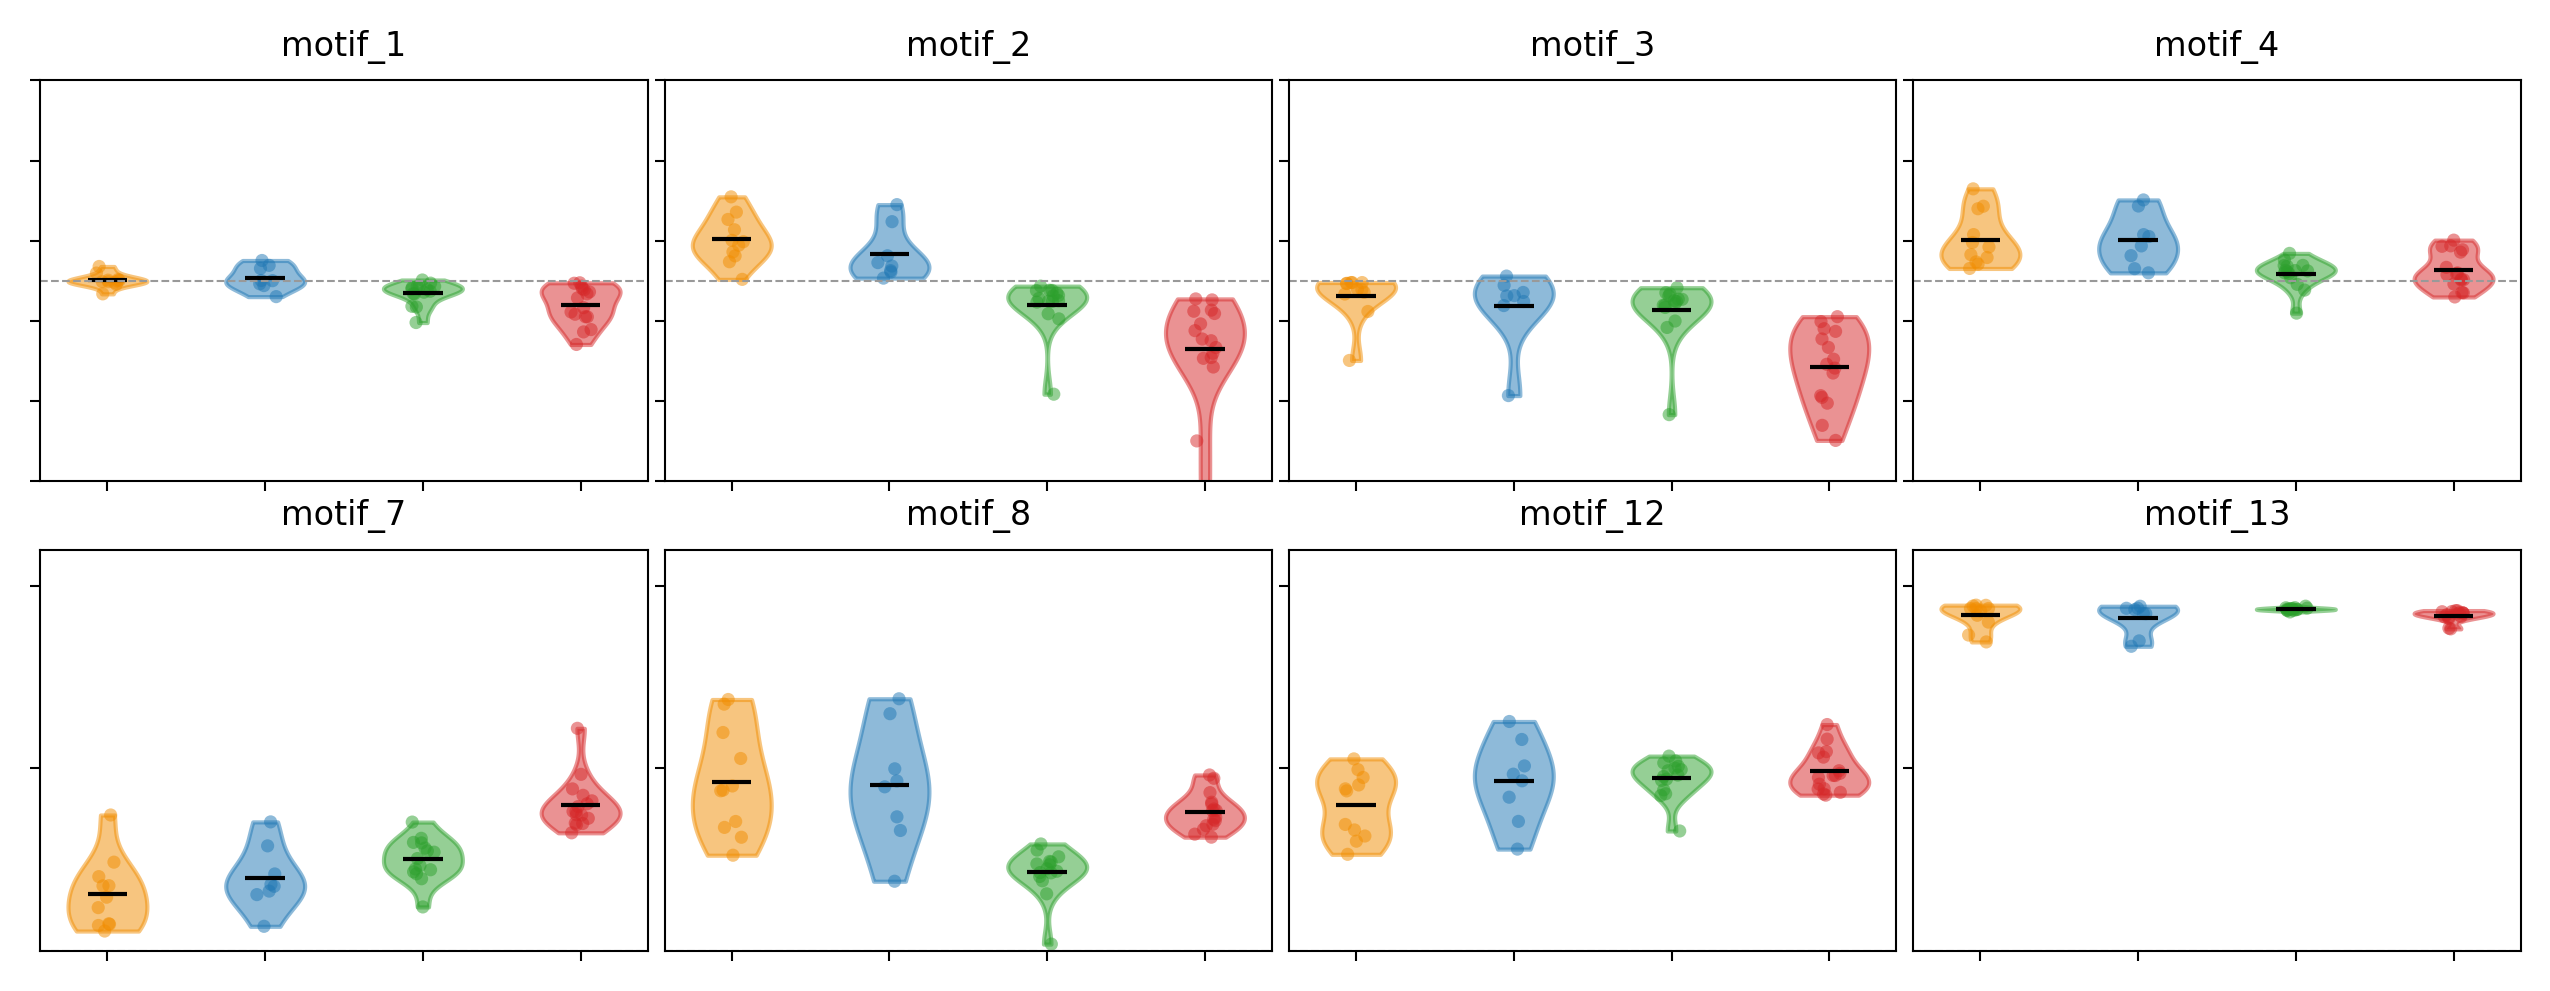

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ===========================
# Assumed existing:
# NZ     : (n_region, 13)
# labels : (n_region,) values in {1,2,3,4} (can include 0)
# ===========================

# ----- Single panel size (cm -> inch) -----
fig_w_cm, fig_h_cm = 5.3, 4.0
fig_w_in, fig_h_in = fig_w_cm / 2.54, fig_h_cm / 2.54

# ----- Grid layout for 13 motifs -----
n_motif = 13
ncols = 4
nrows = 2  # 5 rows for 13 motifs

# Big figure size (approx: each panel uses fig_w_in x fig_h_in)
big_w = fig_w_in * ncols
big_h = fig_h_in * nrows

# ----- Cluster info / colors / test pairs -----
unique_clusters = np.array(sorted(np.unique(labels).tolist()))
n_clust = len(unique_clusters)
colors = ["#F18D00","#1f77b4","#2ca02c","#d62728"]

# colors = {
#     "MOp":     "#2ca02c",
#     "FRP":     "#F18D00",
#     "CA1":     "#1f77b4",
#     "AUDp":    "#d62728"
# }

pairs = [(1, 2), (2, 3), (3, 4), (1, 4)]

fig, axes = plt.subplots(nrows, ncols, figsize=(big_w, big_h), squeeze=False)
axes = axes.ravel()

i=0
for j in [0,1,2,3,6,7,11,12]:
    ax = axes[i]
    i = i + 1
    # ----- 0) transform + drop invalid values (per motif) -----
    raw = 1 + 8 * NZ[:, j]
    mask = np.isfinite(raw) & (raw > 0) & np.isfinite(labels)
    vals = np.log10(raw[mask])
    labj = labels[mask]

    # ----- 1) violin data by cluster -----
    data_by_cluster = [vals[labj == c] for c in unique_clusters]

    parts = ax.violinplot(
        data_by_cluster,
        positions=np.arange(1, n_clust + 1),
        showmeans=True,
        showextrema=False,
        showmedians=False,
    )

    for body, col in zip(parts["bodies"], colors):
        body.set_facecolor(col)
        body.set_edgecolor(col)
        body.set_alpha(0.5)

    if "cmeans" in parts and parts["cmeans"] is not None:
        parts["cmeans"].set_color("k")
        parts["cmeans"].set_linewidth(1.0)

    # ----- 2) scatter points with jitter -----
    for i_pos, c in enumerate(unique_clusters, start=1):
        vc = vals[labj == c]
        if len(vc) == 0:
            continue
        jitter = (np.random.rand(len(vc)) - 0.5) * 0.15
        x_pos = np.full(len(vc), i_pos) + jitter
        ax.scatter(x_pos, vc, s=10, alpha=0.5, color=colors[i_pos - 1], edgecolors="none")

    # ----- 3) y-range / ticks -----
    if j in (0,1,2,3):
        y_low, y_high = -1, 1
        ax.set_yticks(np.arange(-1, 1.01, 0.4))
    else:
        y_low, y_high = 0.0, 1.1
        ax.set_yticks([0.5, 1.0])

    ax.set_ylim(y_low, y_high)
    ax.axhline(0, color="0.6", lw=0.5, ls="--")

    # ----- 4) title / ticks -----
    ax.set_title(f"motif_{j+1}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(1, n_clust + 1))
    ax.tick_params(axis="x", which="both", labelbottom=False)
    ax.tick_params(axis="y", which="both", labelleft=False)

    # ----- 5) spine/tick styling -----
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)
    ax.tick_params(axis="both", which="both", width=0.5, length=2.5)

# Hide unused subplots (there will be 15 slots for 13 motifs)
for k in range(n_motif, nrows * ncols):
    axes[k].axis("off")

plt.tight_layout(pad=0.2)
plt.savefig("motif_violin_all_in_one.svg", transparent=True, bbox_inches="tight")
plt.show()